In [1]:
import pandas as pd
import pickle

In [2]:
pred_dfs_path = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/evals/cluster_iat/vL_both_pred_dfs-PeskaVLP-include_none_label=100-label_count_filter=20.pkl'

with open(pred_dfs_path, 'rb') as f:
    pred_dfs = pickle.load(f)

In [3]:
keys = list(pred_dfs.keys())
instrument_df = pred_dfs[keys[0]]
action_df = pred_dfs[keys[1]]
tissue_df = pred_dfs[keys[2]]

cols = ['Dialogue', 'Timestamp', 'Case', 'label', 'pred', 'cvid']
instrument_df = instrument_df[cols]
action_df = action_df[cols]
tissue_df = tissue_df[cols]

instrument_df = instrument_df.rename(columns={'label': 'instrument-label', 'pred': 'instrument-pred'})
action_df = action_df.rename(columns={'label': 'action-label', 'pred': 'action-pred'})
tissue_df = tissue_df.rename(columns={'label': 'tissue-label', 'pred': 'tissue-pred'})

instrument_df['instrument-correct'] = instrument_df['instrument-label'] == instrument_df['instrument-pred']
action_df['action-correct'] = action_df['action-label'] == action_df['action-pred']
tissue_df['tissue-correct'] = tissue_df['tissue-label'] == tissue_df['tissue-pred']

merge_on_cols = ['Dialogue', 'Timestamp', 'Case']
merge_df = instrument_df.merge(action_df[merge_on_cols + ['action-label', 'action-pred', 'action-correct'] + ['cvid']], on=['Dialogue', 'Timestamp', 'Case'], how='outer')
merge_df = merge_df.merge(tissue_df[merge_on_cols + ['tissue-label', 'tissue-pred', 'tissue-correct'] + ['cvid']], on=['Dialogue', 'Timestamp', 'Case'], how='outer')

merge_df['valid'] = merge_df.apply(lambda row: True if False not in {row['instrument-correct'], row['action-correct'], row['tissue-correct']} else False, axis=1)

merge_df['cvid'] = merge_df.apply(lambda row: row['cvid'] if pd.notna(row['cvid']) else (row['cvid_x'] if pd.notna(row['cvid_x']) else row['cvid_y']), axis=1)
merge_df = merge_df.drop(columns=['cvid_x', 'cvid_y'])

merge_df = merge_df.reset_index(drop=True)

In [4]:
merge_df.head(2)

,Dialogue,Timestamp,Case,instrument-label,instrument-pred,instrument-correct,action-label,action-pred,action-correct,tissue-label,tissue-pred,tissue-correct,cvid,valid
0,(explaining sutures),18:07:39,9,suturing_tools,suturing_tools,True,NaN,NaN,NaN,NaN,NaN,NaN,c9_s0_1-59-56.avi,True
1,*responding to fellow q* just leave it alone,16:53:44,7,NaN,NaN,NaN,release_instrument,open_spread,False,NaN,NaN,NaN,c7_s0_0-10-22.avi,False


In [5]:
valid_df = merge_df[merge_df['valid']].reset_index(drop=True)
print(f'Number of valid rows: {len(valid_df)}')

Number of valid rows: 458


In [6]:
import openai
import backoff
import json
import re
import pandas as pd
import numpy as np
import string
import random
import os

import sys
sys.path.append('..')
from utils import set_envvars
ENVVARS = set_envvars(constants_path='../constants.json')

def init_OpenAI(key):
  client = openai.OpenAI(
    # This is the default and can be omitted
    api_key=key,
  )
  return client

def list_models(client):
  models = client.models.list()
  model_names = [model.id for model in models.data]
  return model_names

def generate_GPT(client, model_name, instruction, label_prompt, temperature=0.0):
  @backoff.on_exception(backoff.expo, (openai.RateLimitError,
                                       openai.APIError,
                                       ConnectionResetError,
                                       json.decoder.JSONDecodeError))

  def completions_with_backoff(**kwargs):
    return client.chat.completions.create(**kwargs)

  resp = []
  # Prompt OpenAI
  # https://github.com/openai/openai-python
  response = completions_with_backoff(model=model_name,
                                      temperature=temperature,
                                      messages=[{"role": "system", "content": instruction},
                                                {"role": "user",   "content": label_prompt}])

  gen = response.choices[0].message.content
  return gen

In [13]:
import subprocess
import cv2

def convert_avi_to_mp4(avi_file_path: str, output_mp4_path: str, overwrite: bool = False) -> bool:
    """Convert AVI video to MP4 format using ffmpeg."""
    output_file = output_mp4_path
    if not overwrite and os.path.exists(output_file):
        return False
    elif overwrite and os.path.exists(output_file):
        os.remove(output_file)
    
    command = [
        "ffmpeg",
        "-i", avi_file_path,
        "-ac", "2",
        "-b:v", "2000k",
        "-c:a", "aac",
        "-c:v", "libx264",
        "-b:a", "160k",
        "-vprofile", "high",
        "-bf", "0",
        "-strict", "experimental",
        "-f", "mp4",
        output_file
    ]
    
    try:
        subprocess.check_output(command, stderr=subprocess.STDOUT)
    except subprocess.CalledProcessError as e:
        print("Error converting video:")
        print(e.output.decode())
        return False
    
    return True

def load_video(video_path: str, target_fps: int = None) -> np.ndarray:
    # Load video file
    video = cv2.VideoCapture(video_path)

    # Get video properties
    frame_width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video.get(cv2.CAP_PROP_FPS)
    
    if target_fps is not None and target_fps < fps:
        frame_interval = int(round(fps / target_fps))
    
    # Initialize list to store frames
    frames = []

    # Read frames from video
    frame_count = 0
    while True:
        success, frame = video.read()
        if not success:
            break
            
        if frame_count % frame_interval == 0:
            frames.append(frame)
        frame_count += 1

    # Convert to numpy array
    frames = np.array(frames)

    # Release video object
    video.release()
    
    return frames

CLIPS_DATA_DIR = "/home/firdavs/surgery/clips_with_wiggle/fb_clips_wiggle"
example_avi_path = os.path.join(CLIPS_DATA_DIR, valid_df['cvid'].iloc[0])
example_mp4_path = os.path.join('../tmp', valid_df['cvid'].iloc[0].replace('.avi', '.mp4'))
print(f'Converting {example_avi_path} to {example_mp4_path}')
convert_avi_to_mp4(example_avi_path, example_mp4_path, overwrite=True)

frames = load_video(example_mp4_path, target_fps=1)
iat = (valid_df['instrument-correct'].iloc[0], valid_df['action-correct'].iloc[0], valid_df['tissue-correct'].iloc[0])

Converting /home/firdavs/surgery/clips_with_wiggle/fb_clips_wiggle/c9_s0_1-59-56.avi to ../tmp/c9_s0_1-59-56.mp4


In [14]:
len(frames)

11

In [15]:
import base64
def generate_feedback_from_frames_and_iat(client, model_name, instruction, frames, iat, temperature=0.0):
    @backoff.on_exception(backoff.expo, (openai.RateLimitError,
                                       openai.APIError,
                                       ConnectionResetError,
                                       json.decoder.JSONDecodeError))

    def completions_with_backoff(**kwargs):
        return client.chat.completions.create(**kwargs)
    
    user_messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Video Frames:"},
            ]
        }
    ]
    for frame in frames:
        # Convert frame to base64 string for API
        _, img_encoded = cv2.imencode('.jpg', frame)
        base64_image = base64.b64encode(img_encoded).decode('utf-8')
        
        user_messages.append({
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        })
    user_messages.append(
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "IAT Triplet:\ninstrument: <INSTRUMENT>, action: <ACTION>, tissue: <TISSUE>"}
            ]
        }
    )
    # Prompt OpenAI
    # https://github.com/openai/openai-python
    messages = [{"role": "system", "content": instruction}] + user_messages
    
    response = completions_with_backoff(model=model_name,
                                        temperature=temperature,
                                        messages=messages)

    gen = response.choices[0].message.content
    return gen

def generate_random_feedback(client, model_name, instruction, temperature=0.0):
    @backoff.on_exception(backoff.expo, (openai.RateLimitError,
                                       openai.APIError,
                                       ConnectionResetError,
                                       json.decoder.JSONDecodeError))

    def completions_with_backoff(**kwargs):
        return client.chat.completions.create(**kwargs)
    
    # Prompt OpenAI
    # https://github.com/openai/openai-python
    messages = [{"role": "system", "content": "instruction"}]
    
    response = completions_with_backoff(model=model_name,
                                        temperature=temperature,
                                        messages=messages)

    gen = response.choices[0].message.content
    return gen

In [16]:
client = init_OpenAI(key=os.environ['OPENAI_API_KEY'])
available_models = list_models(client)
print(f'Available models: {available_models}')

Available models: ['gpt-4-0613', 'gpt-4', 'gpt-3.5-turbo', 'o4-mini-deep-research-2025-06-26', 'o3-pro-2025-06-10', 'o4-mini-deep-research', 'o3-deep-research', 'o3-deep-research-2025-06-26', 'davinci-002', 'babbage-002', 'gpt-3.5-turbo-instruct', 'gpt-3.5-turbo-instruct-0914', 'dall-e-3', 'dall-e-2', 'gpt-4-1106-preview', 'gpt-3.5-turbo-1106', 'tts-1-hd', 'tts-1-1106', 'tts-1-hd-1106', 'text-embedding-3-small', 'text-embedding-3-large', 'gpt-4-0125-preview', 'gpt-4-turbo-preview', 'gpt-3.5-turbo-0125', 'gpt-4-turbo', 'gpt-4-turbo-2024-04-09', 'gpt-4o', 'gpt-4o-2024-05-13', 'gpt-4o-mini-2024-07-18', 'gpt-4o-mini', 'gpt-4o-2024-08-06', 'chatgpt-4o-latest', 'o1-preview-2024-09-12', 'o1-preview', 'o1-mini-2024-09-12', 'o1-mini', 'gpt-4o-realtime-preview-2024-10-01', 'gpt-4o-audio-preview-2024-10-01', 'gpt-4o-audio-preview', 'gpt-4o-realtime-preview', 'omni-moderation-latest', 'omni-moderation-2024-09-26', 'gpt-4o-realtime-preview-2024-12-17', 'gpt-4o-audio-preview-2024-12-17', 'gpt-4o-min

In [17]:
# fb_generation_system_prompt_path = '../prompts/gpt_fb_generation-system.txt'
# fb_generation_system_prompt_path = '../prompts/gpt_fb_generation-system-no_2_6_criteria.txt'
# fb_generation_system_prompt_path = '../prompts/gpt_fb_generation-system-no_criteria.txt'
# fb_generation_system_prompt_path = '../prompts/gpt_fb_generation-system-short.txt'
# fb_generation_system_prompt_path = '../prompts/gpt_fb_generation-system-no_criteria.txt'
fb_generation_system_prompt_path = '../prompts/gpt_fb_generation-system-no_criteria-random.txt'

with open(fb_generation_system_prompt_path, 'r') as f:
    gen_instruction = f.read()

In [18]:
fb = generate_feedback_from_frames_and_iat(client, model_name='gpt-4o', instruction=gen_instruction, frames=frames, iat=iat, temperature=0.0)

In [19]:
fb

'Advance the needle driver to secure the suture on the tissue.'

In [20]:
from tqdm import tqdm
# model = 'gpt-4.1-mini' 
model = 'gpt-4o' 
generated_feedback = []
for i in tqdm(range(len(valid_df))):
    row = valid_df.iloc[i]
    cvid = row['cvid']
    iat = (row['instrument-correct'], row['action-correct'], row['tissue-correct'])
    avi_path = os.path.join(CLIPS_DATA_DIR, cvid)
    mp4_path = os.path.join('../tmp', cvid.replace('.avi', '.mp4'))
    convert_avi_to_mp4(avi_path, mp4_path, overwrite=False)
    frames = load_video(mp4_path, target_fps=1)
    fb = generate_feedback_from_frames_and_iat(client, model_name=model, instruction=gen_instruction, frames=frames, iat=iat, temperature=0.0)
    
    # fb = generate_random_feedback(client, model_name=model, instruction=gen_instruction, temperature=0.0)
    
    generated_feedback.append(fb)
fb_gen_df = valid_df.copy()
fb_gen_df['generated_feedback'] = generated_feedback

100%|██████████| 458/458 [29:40<00:00,  3.89s/it]


In [23]:
fb_gen_path = '../outputs/fb_generation/gpt_fb_gen_df_with_iat-gpt4o'
# fb_gen_path += '-no_2_6_criteria'
fb_gen_path += '-no_criteria'
# fb_gen_path += '-short'

fb_gen_path += '.csv'

fb_gen_df.to_csv(fb_gen_path, index=False)

fb_gen_df = pd.read_csv(fb_gen_path)

In [24]:
fb_gen_df.head()

,Dialogue,Timestamp,Case,instrument-label,instrument-pred,instrument-correct,action-label,action-pred,action-correct,tissue-label,tissue-pred,tissue-correct,cvid,valid,generated_feedback
0,(explaining sutures),18:07:39,9,suturing_tools,suturing_tools,True,NaN,NaN,NaN,NaN,NaN,NaN,c9_s0_1-59-56.avi,True,Advance the needle driver to secure the suture...
1,", I will say it again, this is too medial. thi...",09:30:52,24,NaN,NaN,NaN,NaN,NaN,NaN,vascular_neurovascular_structures,vascular_neurovascular_structures,True,c24_s0_0-26-22.avi,True,Ensure precise dissection and maintain clear v...
2,", if you're going to keep running this one, re...",10:10:51,16,auxiliary_arm,auxiliary_arm,True,traction_retract,traction_retract,True,NaN,NaN,NaN,c16_s0_1-15-55.avi,True,Advance the needle driver to secure the suture.
3,", is that a gigantic suture? how much do you h...",16:17:54,18,suturing_tools,suturing_tools,True,NaN,NaN,NaN,NaN,NaN,NaN,c18_s0_1-45-49.avi,True,"Instrument: Large Needle Driver, Action: Sutur..."
4,", look up, you need to grab this",10:06:49,16,NaN,NaN,NaN,grip_hold,grip_hold,True,NaN,NaN,NaN,c16_s0_1-11-53.avi,True,Advance the needle driver to secure the suture...


In [25]:
with open('../prompts/fb_alignment-system.txt', 'r') as f:
    alignment_instruction = f.read()
with open('../prompts/fb_alignment-user.txt', 'r') as f:
    alignment_label_prompt_template = f.read()

In [26]:
row = fb_gen_df.iloc[0]
gen_fb = row['generated_feedback']
gt_fb = row['Dialogue']

label_prompt = alignment_label_prompt_template.replace('<GEN_FB>', gen_fb)
label_prompt = label_prompt.replace('<GT_FB>', gt_fb)
alignment_score = generate_GPT(client, model_name='gpt-4o', instruction=alignment_instruction, label_prompt=label_prompt, temperature=0.0)

In [27]:
from tqdm import tqdm

model = 'gpt-4.1-mini'
# model = 'gpt-4o'
alignment_score = []
for i in tqdm(range(len(fb_gen_df))):
    row = fb_gen_df.iloc[i]
    gen_fb = row['generated_feedback']
    gt_fb = row['Dialogue']
    label_prompt = alignment_label_prompt_template.replace('<GEN_FB>', gen_fb)
    label_prompt = label_prompt.replace('<GT_FB>', gt_fb)
    score = generate_GPT(client, model_name=model, instruction=alignment_instruction, label_prompt=label_prompt, temperature=0.0)
    alignment_score.append(score)
fb_alignment_df = fb_gen_df.copy()
fb_alignment_df['alignment_score'] = alignment_score

100%|██████████| 458/458 [03:35<00:00,  2.13it/s]


In [28]:
fb_alignment_path = '../outputs/fb_generation/fb_alignment_df-with_iat-gpt4o_with_gpt41mini_scoring'
# fb_alignment_path += '-no_2_6_criteria'
fb_alignment_path += '-no_criteria'
# fb_alignment_path += '-short'

fb_alignment_df.to_csv(fb_alignment_path + '.csv', index=False)

In [29]:
fb_alignment_path

'../outputs/fb_generation/fb_alignment_df-with_iat-gpt4o_with_gpt41mini_scoring-no_criteria'

In [30]:
fb_alignment_df['alignment_score'].value_counts()

alignment_score
2    358
3     76
1     21
4      2
5      1
Name: count, dtype: int64

## Analyze alignment

Name: No criteria (gpt4o)
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Proceed with cutting or dividing as needed.
Alignment Score: 3

Name: No criteria (gpt4o genaration, gpt41mini scoring)
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Proceed with cutting or dividing as needed.
Alignment Score: 3

Name: Full GPT
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Maintain gentle traction on the tissue while securing the clips.
Alignment Score: 2

Name: Full GPT (gpt4o generation, gpt41mini scoring)
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Maintain gentle traction on the tissue while securing the clips.
Alignment Score: 2

Name: Full GPT (random)
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue

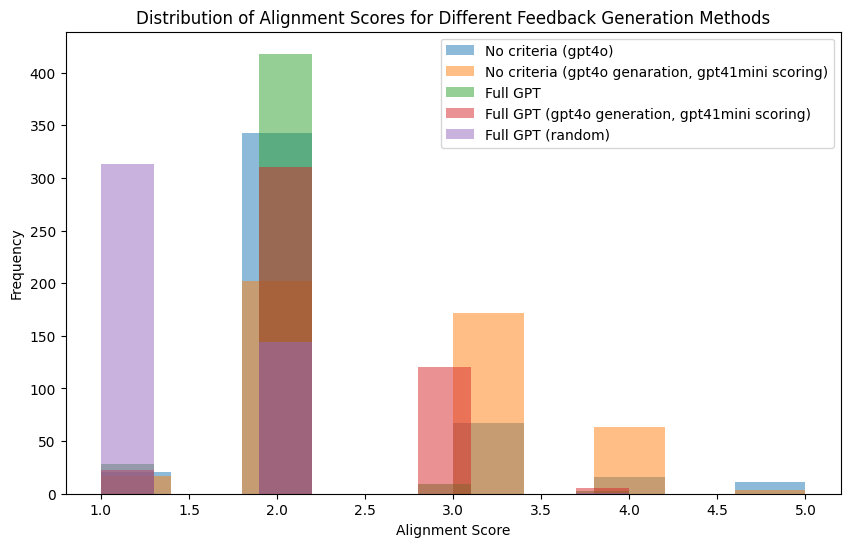

In [21]:
import matplotlib.pyplot as plt

rows = []

plt.figure(figsize=(10, 6))
for name, fb_alignment_path in [
    ('No criteria (gpt4o)', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-gpt4o-no_criteria.csv'),
    ('No criteria (gpt4o genaration, gpt41mini scoring)', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-gpt4o_with_gpt41mini_scoring-no_criteria.csv'),
    ('Full GPT', '../outputs/fb_generation/fb_alignment_df-full_gpt-gpt4o-no_criteria.csv'),
    ('Full GPT (gpt4o generation, gpt41mini scoring)', '../outputs/fb_generation/fb_alignment_df-full_gpt-gpt4o_with_gpt41mini_scoring-no_criteria.csv'),
    ('Full GPT (random)', '../outputs/fb_generation/fb_alignment_df_random-full_gpt-gpt4o_with_gpt41mini_scoring-no_criteria.csv')
]:
    fb_alignment_df = pd.read_csv(fb_alignment_path)
    plt.hist(fb_alignment_df['alignment_score'], bins=10, alpha=0.5, label=name)
    plt.legend()
    
    rows.append({
        'Condition': f'score, {name}',
        'Mean': fb_alignment_df['alignment_score'].mean(),
        'Median': fb_alignment_df['alignment_score'].median(),
        '% >= 3': (fb_alignment_df['alignment_score'] >= 3).mean() * 100,
        '% at 1': (fb_alignment_df['alignment_score'] == 1).mean() * 100,
        'N': len(fb_alignment_df),
    })
    
    print('='*100)
    print(f"Name: {name}")
    for i, example_num in enumerate([94]):
        print(f"Example {i + 1}, 'Dialogue': {fb_alignment_df['Dialogue'].iloc[example_num]}")
        print(f"IAT(instrument: {fb_alignment_df['instrument-label'].iloc[example_num]}, action: {fb_alignment_df['action-label'].iloc[example_num]}, tissue: {fb_alignment_df['tissue-label'].iloc[example_num]})")
        print(f"Generated Feedback: {fb_alignment_df['generated_feedback'].iloc[example_num]}")
        print(f"Alignment Score: {fb_alignment_df['alignment_score'].iloc[example_num]}")
        print()
    print('='*100)

plt.xlabel('Alignment Score')
plt.ylabel('Frequency')
plt.title('Distribution of Alignment Scores for Different Feedback Generation Methods')
plt.show()

In [22]:
fb_alignment_df['Dialogue'].tolist().index("no, open the superficial layer first")

193

In [23]:
fb_alignment_df[fb_alignment_df['alignment_score'] == 5]

,Dialogue,Timestamp,Case,instrument-label,instrument-pred,instrument-correct,action-label,action-pred,action-correct,tissue-label,tissue-pred,tissue-correct,cvid,valid,generated_feedback,alignment_score


In [24]:
analysis_df = pd.DataFrame(rows)
analysis_df.round(3)

,Condition,Mean,Median,% >= 3,% at 1,N
0,"score, No criteria (gpt4o)",2.242,2.0,20.524,4.585,458
1,"score, No criteria (gpt4o genaration, gpt41min...",2.640,3.0,52.183,3.712,458
2,"score, Full GPT",1.972,2.0,2.620,6.114,458
3,"score, Full GPT (gpt4o generation, gpt41mini s...",2.234,2.0,27.293,5.022,458
4,"score, Full GPT (random)",1.321,1.0,0.218,68.341,458
